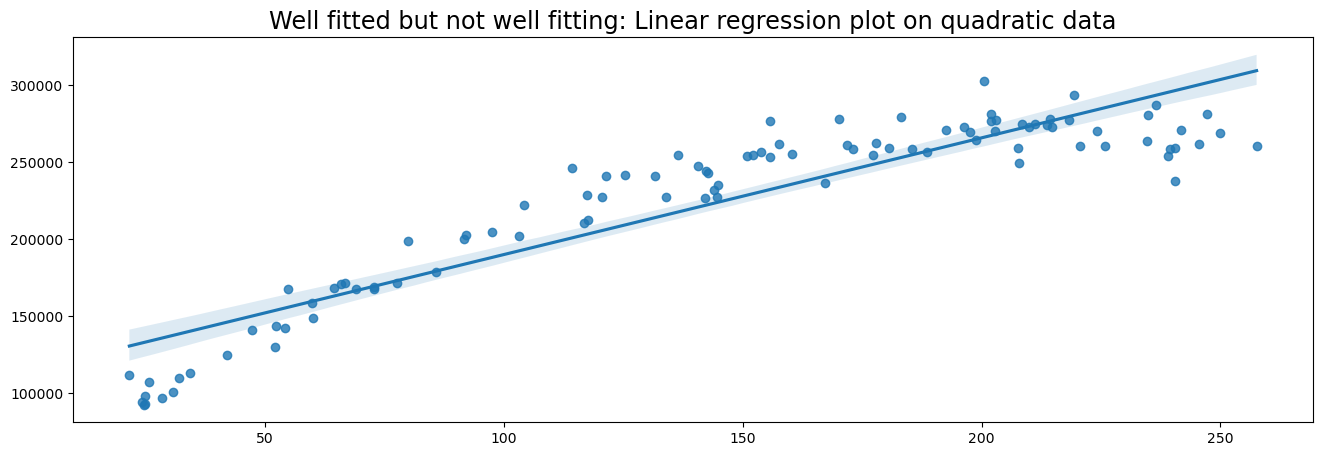

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate data
x = np.random.uniform(low=20, high=260, size=100)
y = 50000 + 2000*x - 4.5*x**2 + np.random.normal( size=100, loc=0, scale=10000)

# Plot
plt.figure(figsize=(16,5))

plt.title(  'Well fitted but not well fitting: Linear regression plot on quadratic data',  fontsize='xx-large')
sns.regplot(x=x, y=y)
plt.show()

Slope: 5.161334345852071
Intercept: -8.529298310742414


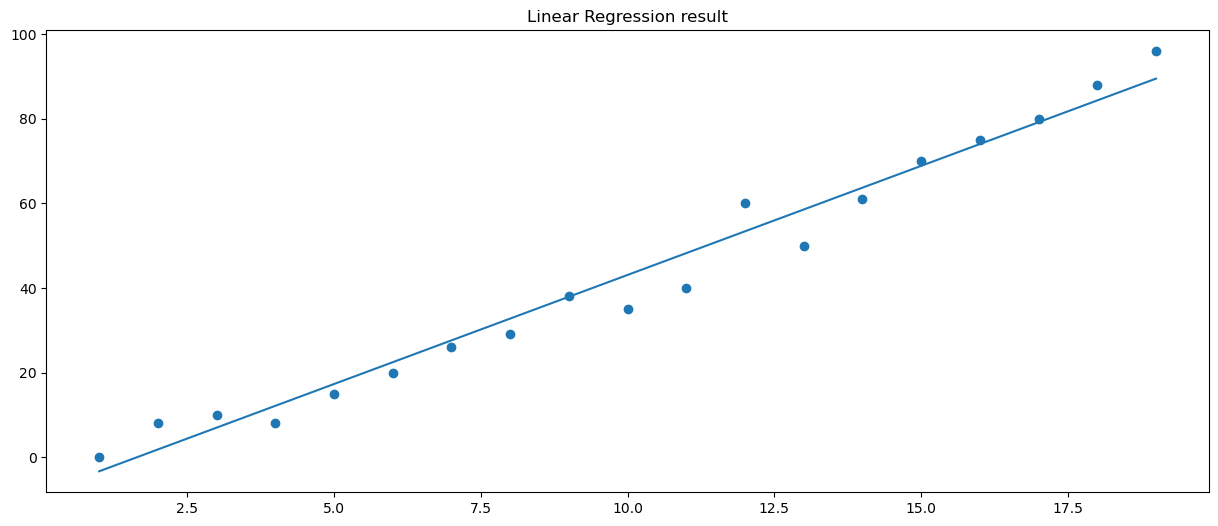

In [7]:
# Linear regression from scratch
import random
# Create data from regression
xs = np.array(range(1,20))
ys = [0,8,10,8,15,20,26,29,38,35,40,60,50,61,70,75,80,88,96]

# Put data in dictionary
data = dict()
for i in list(xs):
    data.update({xs[i-1] : ys[i-1]})

# Slope
m = 0
# y intercept
b = 0
# Learning rate
lr = 0.0001
# Number of epochs
epochs = 100000

# Formula for linear line
def lin(x):
    return m * x + b

# Linear regression algorithm
for i in range(epochs):
    # Pick a random point and calculate vertical distance and horizontal distance
    rand_point = random.choice(list(data.items()))
    vert_dist = abs((m * rand_point[0] + b) - rand_point[1])
    hor_dist = rand_point[0]

    if (m * rand_point[0] + b) - rand_point[1] < 0:
        # Adjust line upwards
        m += lr * vert_dist * hor_dist
        b += lr * vert_dist   
    else:
        # Adjust line downwards
        m -= lr * vert_dist * hor_dist
        b -= lr * vert_dist
        
# Plot data points and regression line
plt.figure(figsize=(15,6))
plt.scatter(data.keys(), data.values())
plt.plot(xs, lin(xs))
plt.title('Linear Regression result')  
print('Slope: {}\nIntercept: {}'.format(m, b))

In [8]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample

# Random sample from Income column
data = df['Income'].sample(n=10000, random_state=1)

# Create bootstrap sample
boot = resample(data, replace=True, n_samples=10, random_state=1)

# Print results
print('Bootstrap Samples:\n', boot)
print('\nMean of the population:', data.mean())
print('Standard Deviation of the population:', data.std())

# Bootstrap plot
plt.figure(figsize=(10, 5))
pd.plotting.bootstrap_plot(data, size=50, samples=500)
plt.show()

NameError: name 'df' is not defined

Index(['Number', 'City', 'Gender', 'Age', 'Income', 'Illness'], dtype='object')
Bootstrap Samples:
 48774      86535.0
95182      90549.0
21107      91164.0
30985     105711.0
100501     91466.0
15374      43607.0
102767    140899.0
91571      99905.0
105716    125992.0
46608     102065.0
Name: Income, dtype: float64

Mean of the population: 91118.9108
Standard Deviation of the population: 25014.195062130235


<Figure size 1000x500 with 0 Axes>

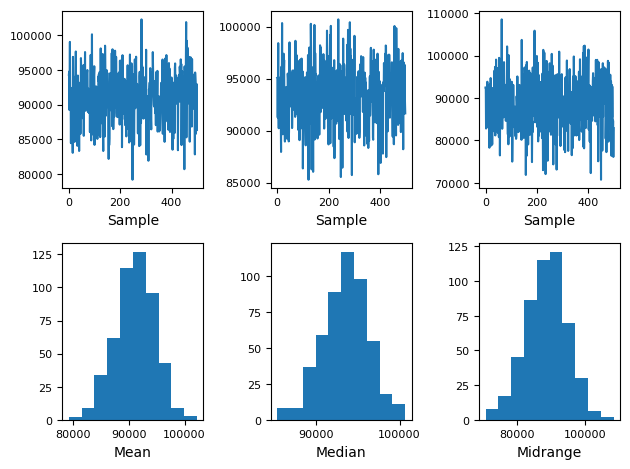

In [9]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample

# Load dataset
df = pd.read_csv("toy_dataset.csv")

# Check columns
print(df.columns)

# Random sample from Income column
data = df['Income'].sample(n=10000, random_state=1)

# Create bootstrap sample
boot = resample(data, replace=True, n_samples=10, random_state=1)

# Print results
print('Bootstrap Samples:\n', boot)
print('\nMean of the population:', data.mean())
print('Standard Deviation of the population:', data.std())

# Bootstrap plot
plt.figure(figsize=(10,5))
pd.plotting.bootstrap_plot(data, size=50, samples=500)
plt.show()

In [12]:
import numpy as np
from scipy import stats

print('T-statistics and p-values of two random samples.')

for _ in range(10):
    rand_sample1 = np.random.random_sample(10)
    rand_sample2 = np.random.random_sample(10)

    print(stats.ttest_ind(rand_sample1, rand_sample2))

T-statistics and p-values of two random samples.
TtestResult(statistic=np.float64(0.32887683722676886), pvalue=np.float64(0.7460443041667881), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.7836274574556963), pvalue=np.float64(0.44344853686446883), df=np.float64(18.0))
TtestResult(statistic=np.float64(-0.6092946673114759), pvalue=np.float64(0.5499431117831078), df=np.float64(18.0))
TtestResult(statistic=np.float64(-0.006253627001660655), pvalue=np.float64(0.9950791483635157), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.29081565123547887), pvalue=np.float64(0.7745165871369472), df=np.float64(18.0))
TtestResult(statistic=np.float64(-1.2204047832841816), pvalue=np.float64(0.23805908381650168), df=np.float64(18.0))
TtestResult(statistic=np.float64(-0.09736105173930337), pvalue=np.float64(0.9235155945022397), df=np.float64(18.0))
TtestResult(statistic=np.float64(2.449310169047946), pvalue=np.float64(0.024778748723905848), df=np.float64(18.0))
TtestResult(statistic=np.fl

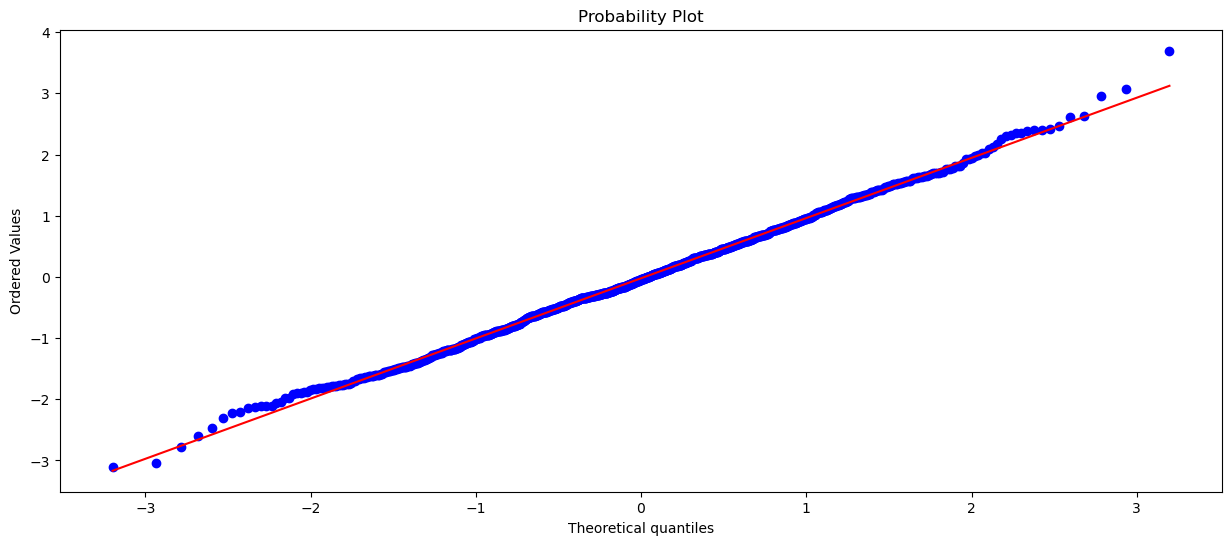

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generate normal distribution data
normal_dist = np.random.normal(loc=0, scale=1, size=1000)

# Q-Q Plot
plt.figure(figsize=(15,6))
stats.probplot(normal_dist, dist="norm", plot=plt)

plt.show()

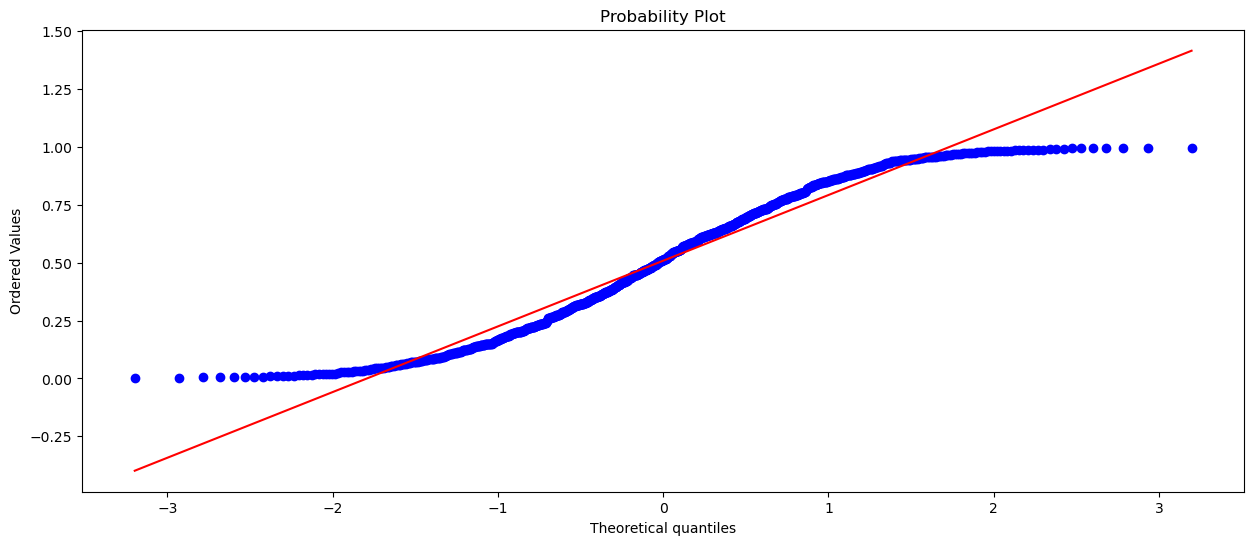

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generate uniform distribution data
uniform_dist = np.random.uniform(low=0, high=1, size=1000)

# Q-Q Plot
plt.figure(figsize=(15,6))
stats.probplot(uniform_dist, dist="norm", plot=plt)

plt.show()

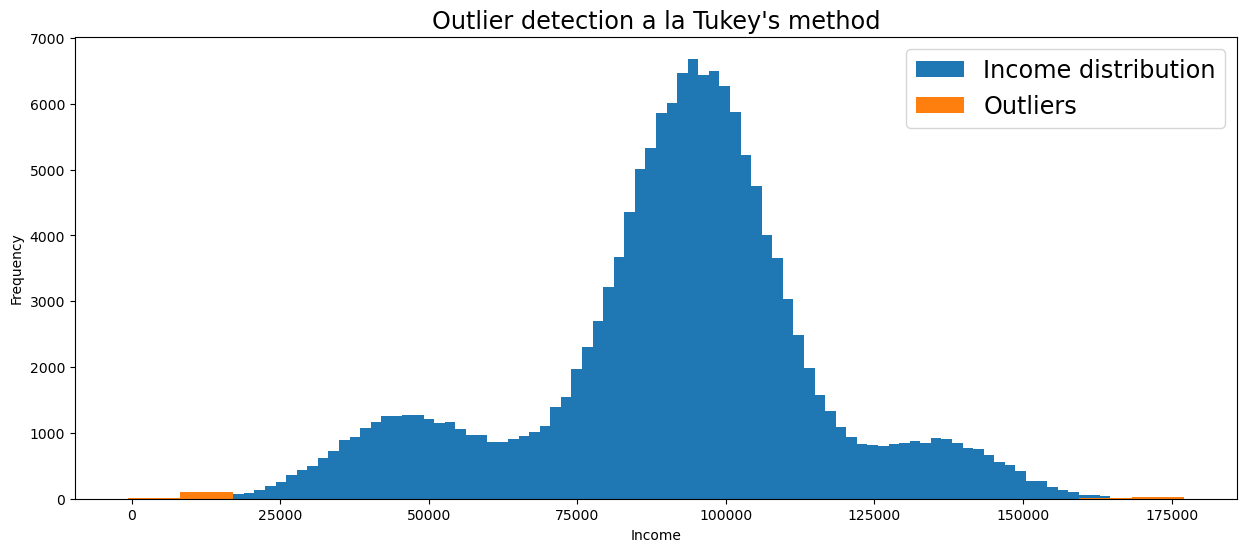

In [18]:
# Detect outliers on the 'Income' column of the Toy Dataset

# Function for detecting outliers a la Tukey's method using z-scores
def tukey_outliers(data) -> list:
    # For more information on calculating the threshold check out:
    # https://medium.com/datadriveninvestor/finding-outliers-in-dataset-using-python-efc3fce6ce32
    threshold = 3
    
    mean = np.mean(data)
    std = np.std(data)
    
    # Spot and collect outliers
    outliers = []
    for i in data:
        z_score = (i - mean) / std
        if abs(z_score) > threshold:
            outliers.append(i)
    return outliers

# Get outliers
income_outliers = tukey_outliers(df['Income'])

# Visualize distribution and outliers
plt.figure(figsize=(15,6))
df['Income'].plot(kind='hist', bins=100, label='Income distribution')
plt.hist(income_outliers, bins=20, label='Outliers')
plt.title("Outlier detection a la Tukey's method", fontsize='xx-large')
plt.xlabel('Income')
plt.legend(fontsize='xx-large')

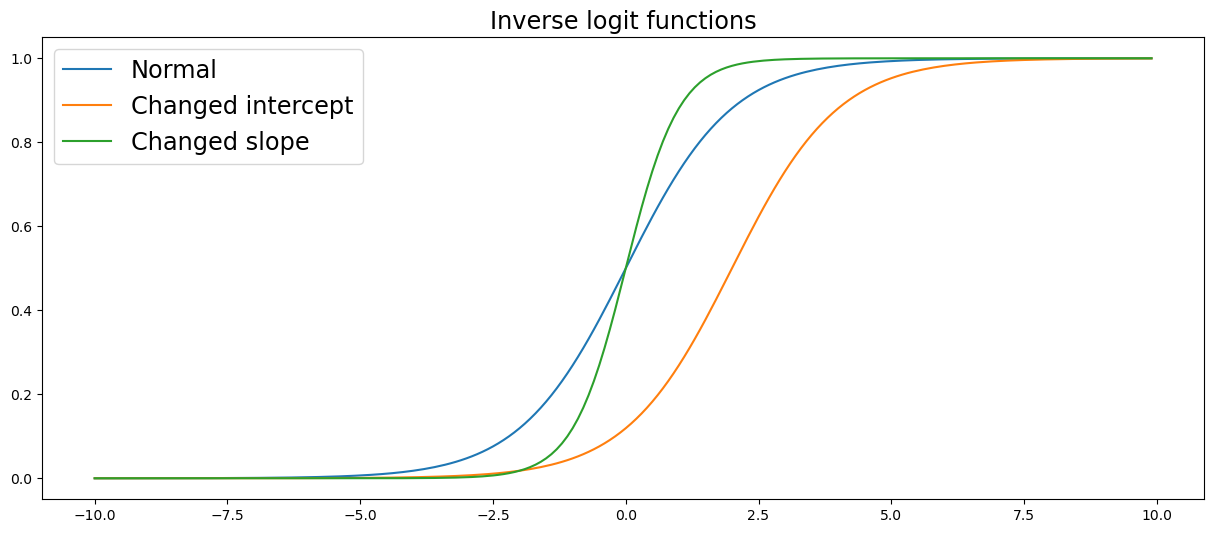

In [19]:
# Inverse logit function (link function)
def inv_logit(x):
    return 1 / (1 + np.exp(-x))

t1 = np.arange(-10, 10, 0.1)
plt.figure(figsize=(15,6))
plt.plot(t1, inv_logit(t1), 
         t1, inv_logit(t1-2),   
         t1, inv_logit(t1*2))
plt.title('Inverse logit functions', fontsize='xx-large')
plt.legend(('Normal', 'Changed intercept', 'Changed slope'), fontsize='xx-large')

In [21]:
# Simple example of Logistic Regression in Python

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# Load dataset
X, y = load_iris(return_X_y=True)

# Logistic Regression model
clf = LogisticRegression(
    random_state=0,
    solver='lbfgs',
    multi_class='multinomial',
    max_iter=200
).fit(X, y)

# Accuracy score
print('Accuracy score of logistic regression model on the Iris flower dataset: {}'.format(clf.score(X, y)))

Accuracy score of logistic regression model on the Iris flower dataset: 0.9733333333333334


C:\Users\Aisharani Patro\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
